In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn import pipeline


In [70]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [71]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [72]:
df.shape

(45000, 14)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [154]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [75]:
df.duplicated().sum()

np.int64(0)

In [77]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [78]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

In [91]:
num_col = df.select_dtypes(include=['int64','float64']).columns.tolist()

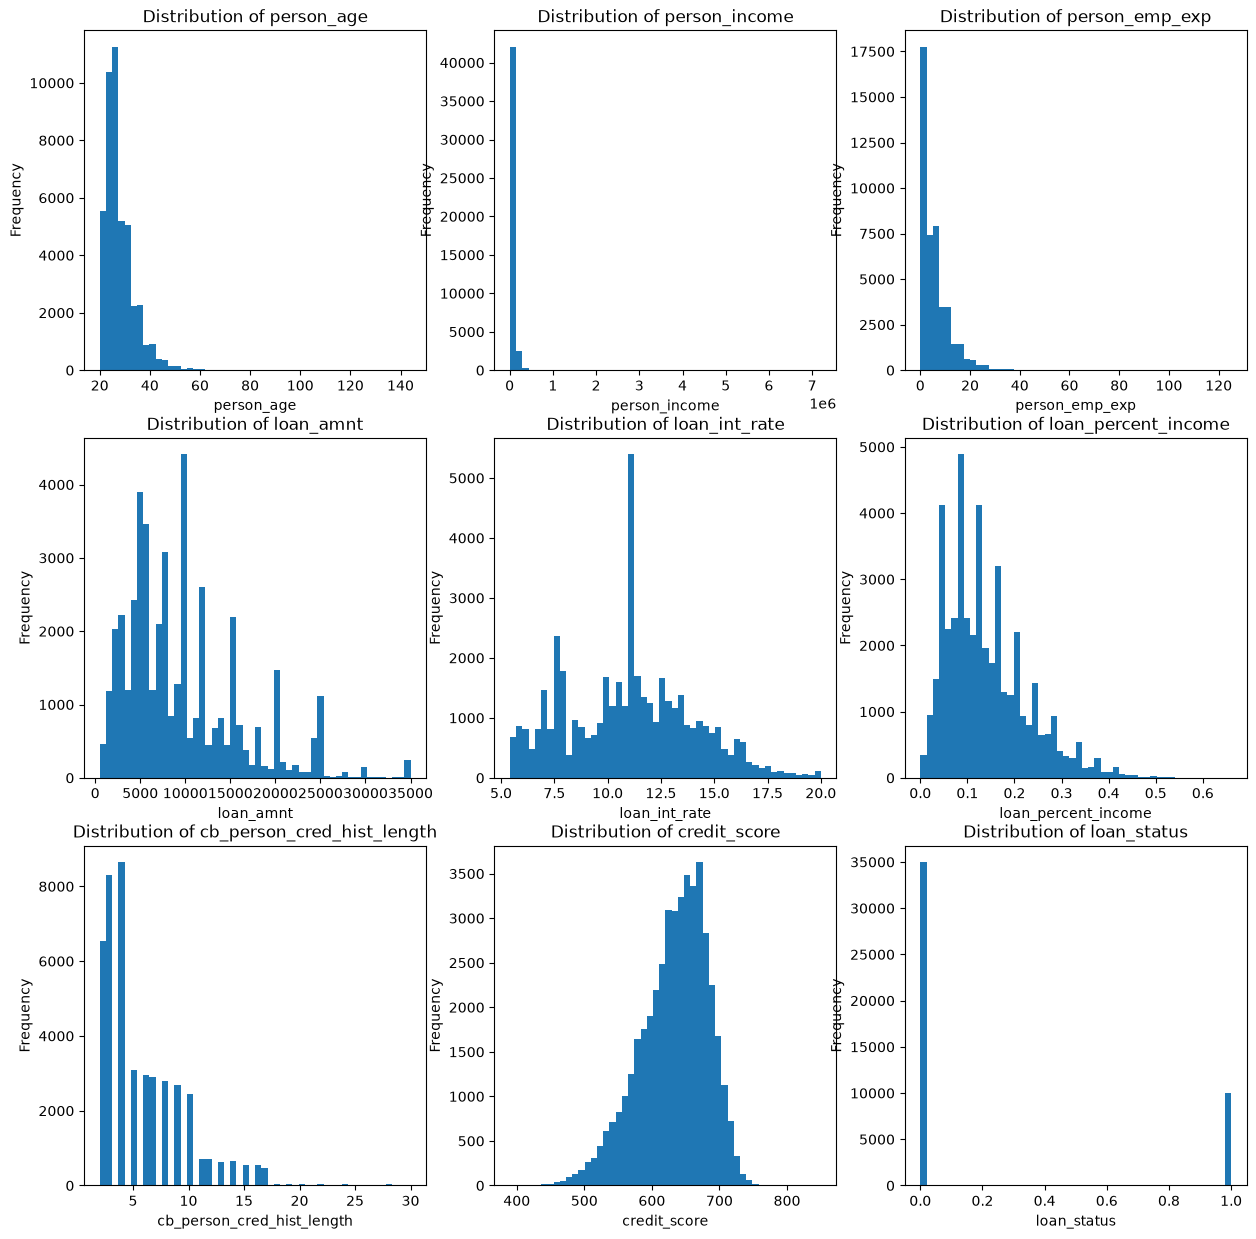

In [99]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,num_col):
    ax.hist(df[col],bins = 50)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')


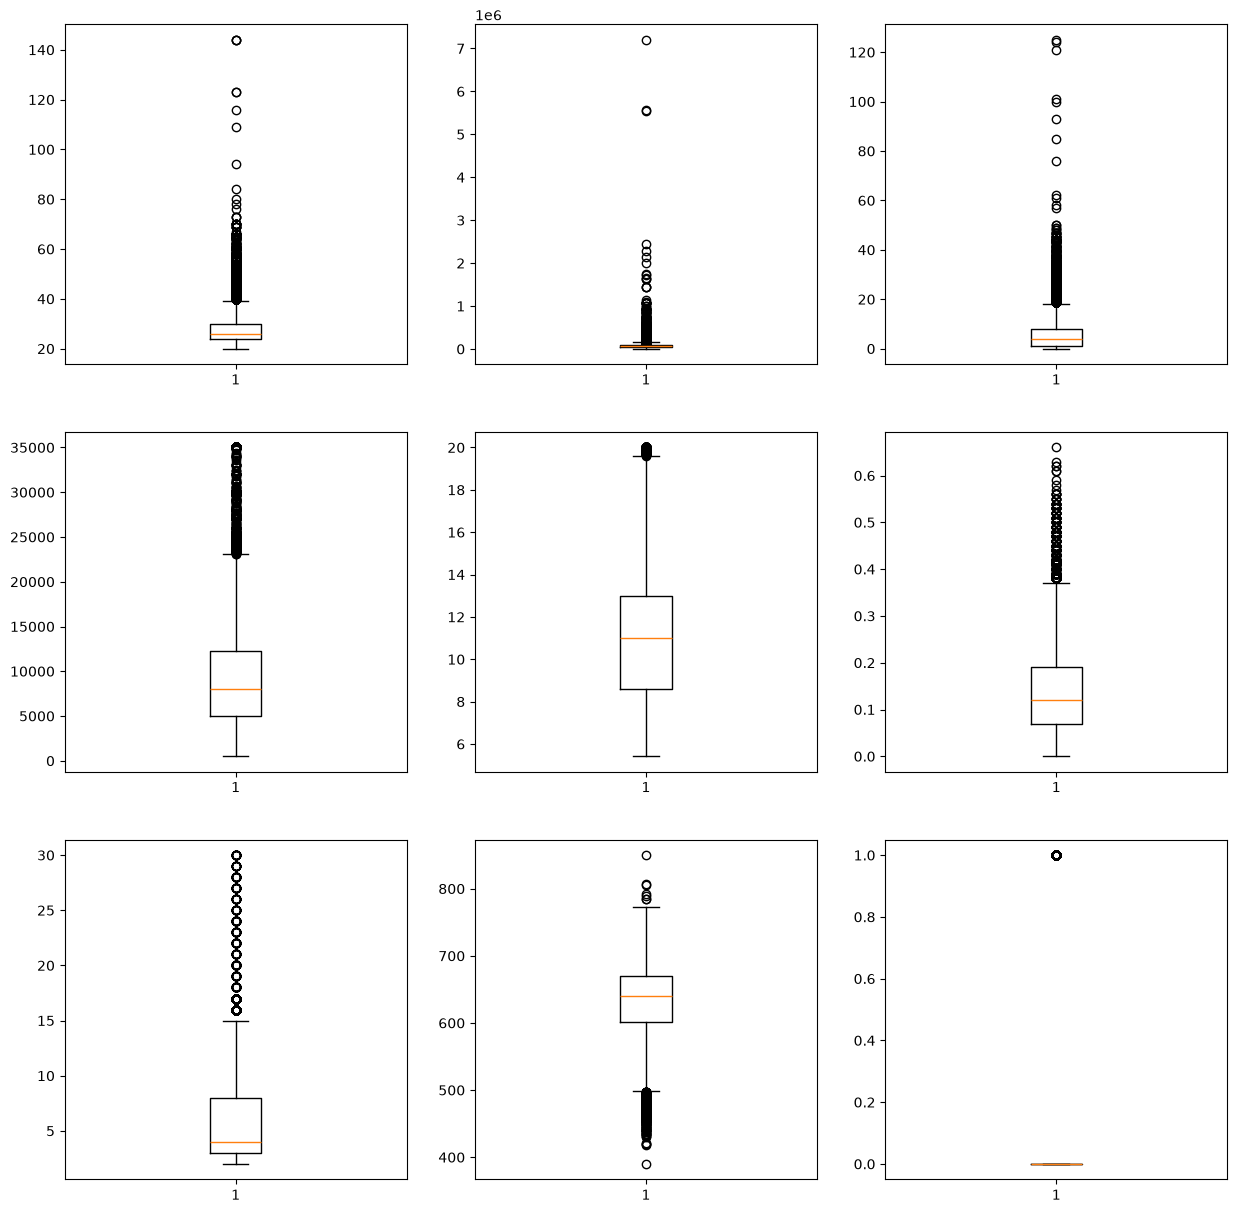

In [101]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,num_col):
    ax.boxplot(df[col])

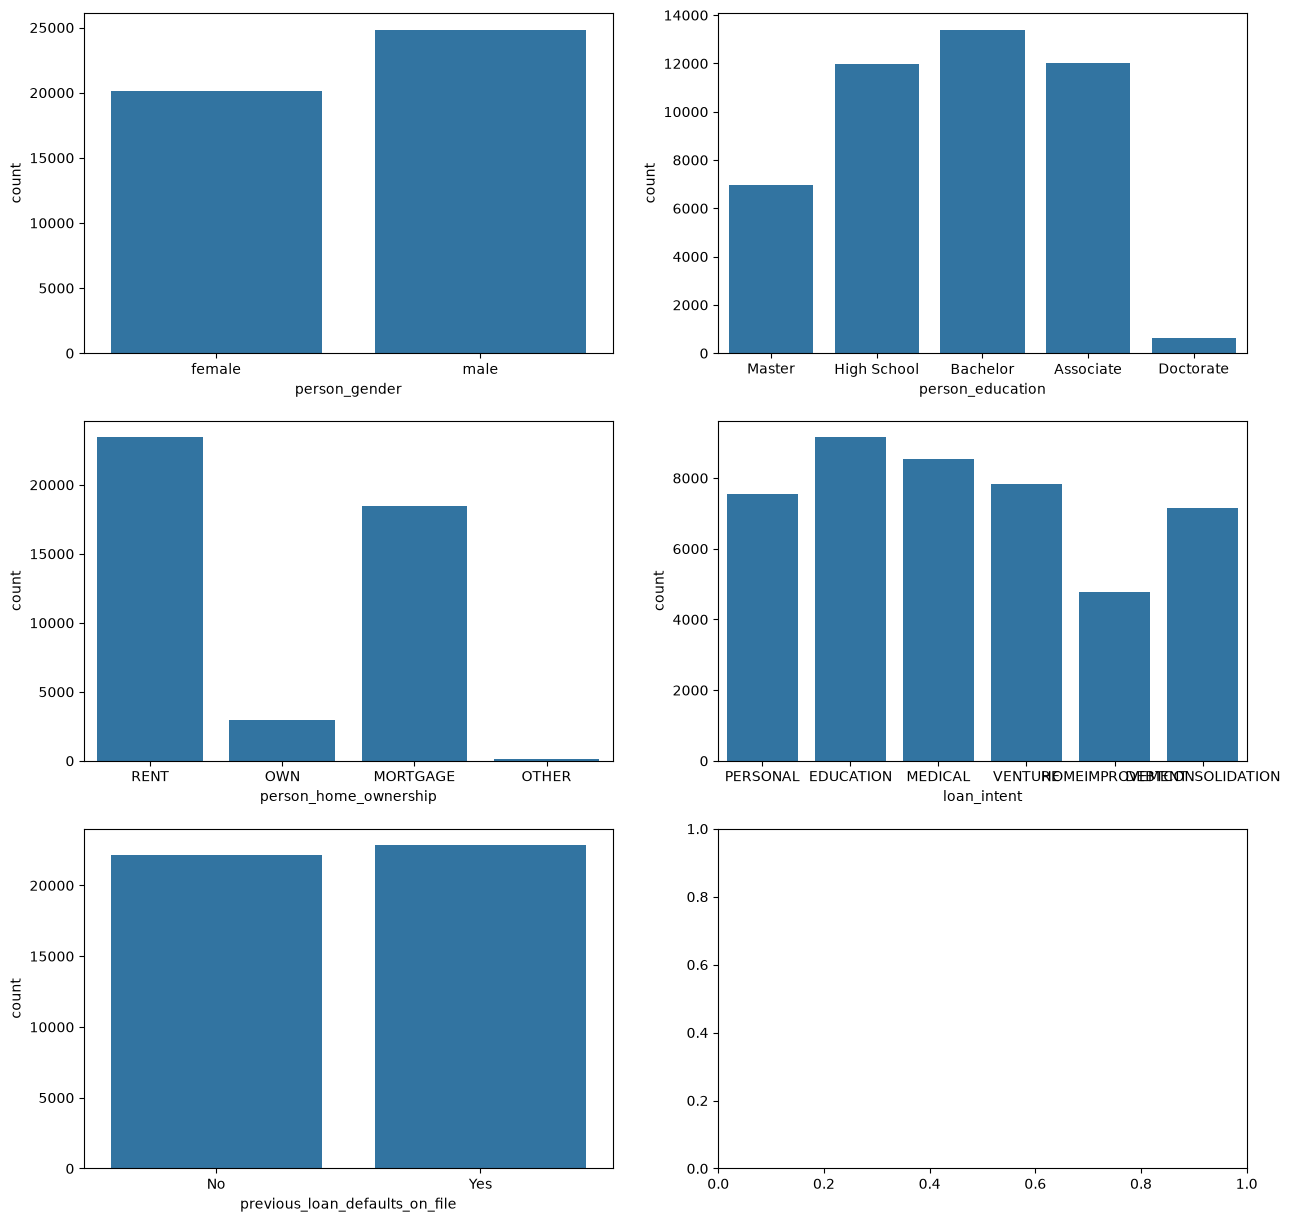

In [114]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,cat_col):
    sns.countplot(data = df,x = df[col],ax= ax)

In [104]:
cat_col = df.select_dtypes(include=['str']).columns.tolist()

<Axes: xlabel='loan_status', ylabel='credit_score'>

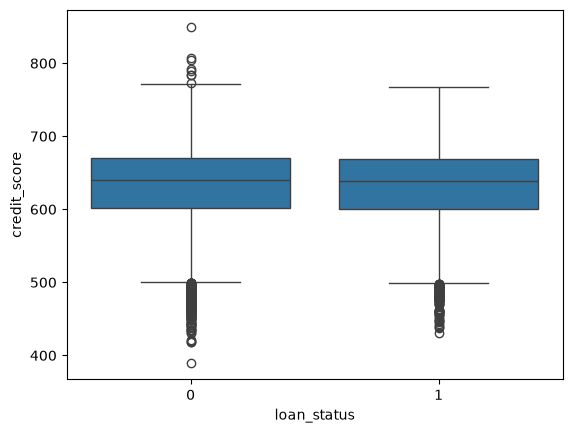

In [118]:
sns.boxplot(data = df,x= 'loan_status',y = 'credit_score')

In [120]:
df.groupby('loan_status')['credit_score'].median()

loan_status
0    640.0
1    639.0
Name: credit_score, dtype: float64

<Axes: xlabel='loan_status', ylabel='person_income'>

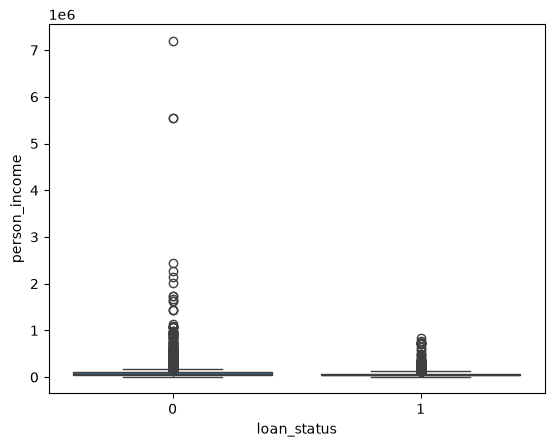

In [121]:
sns.boxplot(data = df,x= 'loan_status',y = 'person_income')

In [124]:
Q1 = df['person_age'].quantile(0.25)

In [126]:
Q3 = df['person_age'].quantile(0.75)

In [127]:
IQR = Q3 - Q1

In [128]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [133]:
df[(df['person_age']<lower )|(df['person_age']>upper)].shape

(2188, 14)

In [138]:
df[df['person_age']>100].shape

(7, 14)

In [139]:
upper

np.float64(39.0)

In [ ]:
Q1_p = df['person_emp_exp'].quantile(0.25)
Q3_p = df['person_emp_exp'].quantile(0.75)
IQR_p = Q3_p - Q1_p
lower_p = Q1_p - 1.5*IQR_p
upper_p = Q3_p + 1.5*IQR_p

In [ ]:
df[(df['person_emp_exp']<lower_p)|(df['person_age']>upper_p)].shape

In [155]:
upper_fill= 50   

In [157]:
lower_p

np.float64(-9.5)

In [153]:
new_df_cap = df.copy()

new_df_cap['person_age'] = np.where(
    new_df_cap['person_age'] > upper,
    upper,
    np.where(
        new_df_cap['person_age'] < lower,
        lower,
        new_df_cap['person_age']
    )
)

In [158]:

new_df_cap['person_emp_exp'] = np.where(
    new_df_cap['person_emp_exp'] > upper_fill,
    upper_fill,new_df_cap['person_emp_exp']
)

In [159]:
new_df_cap

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,18.5,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,18.5,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,18.5,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,18.5,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,18.5,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,18.5,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,18.5,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,18.5,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,18.5,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [160]:
le = LabelEncoder()

In [ ]:
le.fit_transform('')